# DICOM Data Notes

This notebook provides an introduction to the DICOM data storage format, which is widely used in clinical practices for storing medical images.

## Data Sources

The data used in this notebook were retrieved from [Data sets | Aliza Medical Imaging](https://www.aliza-dicom-viewer.com/download/datasets)


In [9]:
from pathlib import Path

import dicomlib

toshiba_aquilion_data = Path('.') / 'data' / 'Toshiba_Aquilion'

dicom_files = list(toshiba_aquilion_data.glob('*.dcm'))


def read_file(fname: Path) -> dicomlib.Dataset:
    """Fix the malformed series by specifying its transfer syntax UID.

    Using the Bee DICOM Viewer application as a comparison against plots in this notebook, inspection indicates that
    the transfer syntax of these images is `ImplicitVRLittleEndian`
    """
    dcm = dicomlib.dcmread(fname, force=True)
    dcm.is_little_endian = True
    dcm.is_implicit_VR = True
    dcm.fix_meta_info()
    return dcm

In [ ]:
from pathlib import Path

ct_nonequi_tilt_data = Path('.') / 'data' / 'ct_nonequi_tilt'

dicom_files = list(ct_nonequi_tilt_data.glob('*.dcm'))

read_file = dicomlib.dcmread  # noqa: F811

In [10]:
import dicomlib

series_instance_uid: set[str | dicomlib.UID | None] = set()
study_instance_uid: set[str | dicomlib.UID | None] = set()
data: list[dicomlib.Dataset] = []

for fname in dicom_files:
    dataset = read_file(fname)
    series_instance_uid.add(dataset.SeriesInstanceUID)
    study_instance_uid.add(dataset.StudyInstanceUID)
    data.append(dataset)

{'SeriesInstanceUID': series_instance_uid, 'StudyInstanceUID': study_instance_uid}

{'SeriesInstanceUID': {'1.2.392.200036.9116.2.6.1.48.1215708991.1267687879.754001'},
 'StudyInstanceUID': {'1.2.392.200036.9123.100.19.1.5.57460649552.20100304153004.1'}}

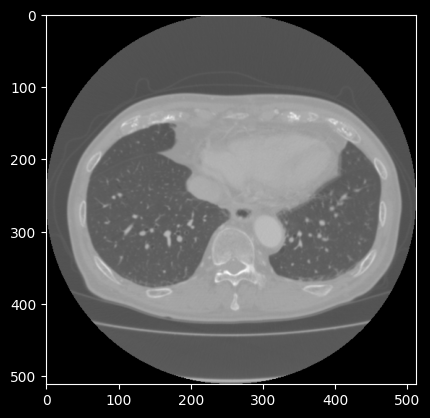

In [11]:
import matplotlib.pyplot as plt

plt.imshow(data[0].pixel_array, cmap='gray')